<a href="https://colab.research.google.com/github/Shofia888/By-Nop4l/blob/main/XAUUSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Jalankan cell ini pertama kali untuk menginstal semua kebutuhan
!pip install yfinance pandas-datareader shap xgboost torch scikit-learn pandas numpy scipy fredapi

In [7]:
# BAGIAN 2: FRED API (Contoh Penempatan API Key Resmi)
try:
    # Mengambil API key dari "Secrets" Google Colab
    from google.colab import userdata
    from fredapi import Fred
    import pandas as pd
    import numpy as np
    from datetime import datetime, timedelta

    # Ambil API key
    fred_api_key = userdata.get('FRED_API_KEY')
    fred = Fred(api_key=fred_api_key)

    # Definisikan rentang waktu (misal 5 tahun terakhir sebagai default jika df_raw tidak ada)
    end_date = datetime.today()
    start_date = end_date - timedelta(days=5 * 365)

    # Gunakan df_raw jika ada, jika tidak gunakan default
    if 'df_raw' in globals():
        obs_start = df_raw.index.min()
        obs_end = df_raw.index.max()
    else:
        obs_start = start_date
        obs_end = end_date

    # Mengambil data 10-Year Treasury Yield (Simbol FRED: DGS10)
    fred_data = fred.get_series('DGS10', observation_start=obs_start, observation_end=obs_end)
    df_fred = pd.DataFrame({'BondYield_10Y': fred_data})
    print("Berhasil mengambil data FRED.")

except Exception as e:
    print(f"Peringatan: Gagal mengambil data FRED ({e}).")
    # Fallback jika gagal
    if 'df_raw' in globals():
        df_fred = pd.DataFrame({'BondYield_10Y': np.nan}, index=df_raw.index)
    else:
        print("Variabel df_raw tidak ditemukan, tidak bisa membuat dataframe dummy.")

Berhasil mengambil data FRED.


In [6]:
from google.colab import userdata
userdata.get('FRED_API_KEY')

'960915ddfcdc738408ebf797358a39f4'

In [8]:
# ==============================================================================
# SISTEM PREDIKSI & ALOKASI XAU/USD (PRODUCTION-READY PIPELINE - UPGRADED)
# ==============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import xgboost as xgb
import shap
import yfinance as yf
from fredapi import Fred
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import norm, skew, kurtosis
import copy
import warnings
warnings.filterwarnings('ignore')

# Set konfigurasi perangkat (GPU jika tersedia)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan perangkat komputasi: {DEVICE}")

# ==============================================================================
# 1. API DATA FETCHER & PREPROCESSING
# ==============================================================================
class DataPipeline:
    def __init__(self, start_date, end_date, api_key=None):
        self.start_date = start_date
        self.end_date = end_date
        self.api_key = api_key
        self.scaler_X = MinMaxScaler()
        self.scaler_y = MinMaxScaler()

    def fetch_data(self):
        print("[1] Mengunduh data dari Yahoo Finance dan FRED...")
        yf_tickers = {'XAUUSD': 'GC=F', 'SP500': '^GSPC', 'NASDAQ': '^IXIC', 'Silver': 'SI=F'}
        df_yf = pd.DataFrame()

        for name, ticker in yf_tickers.items():
            data = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)
            if not data.empty:
                df_yf[name] = data['Close'] if 'Close' in data else data.iloc[:, 3]

        try:
            if self.api_key:
                fred = Fred(api_key=self.api_key)
                fred_data = fred.get_series('DGS10', observation_start=self.start_date, observation_end=self.end_date)
                df_fred = pd.DataFrame({'BondYield_10Y': fred_data})
            else:
                raise ValueError("API Key FRED tidak ditemukan.")
        except Exception as e:
            print(f"Peringatan: Gagal mengambil data FRED ({e}). Menggunakan data dummy.")
            df_fred = pd.DataFrame({'BondYield_10Y': np.random.normal(0.04, 0.005, len(df_yf))}, index=df_yf.index)

        df = df_yf.join(df_fred, how='outer')
        df = df.ffill().bfill()

        for col in df.columns:
            df[f'{col}_Return'] = np.log(df[col] / df[col].shift(1))

        df = df.dropna()
        self.raw_data = df
        return df

    def create_sequences(self, df, target_col='XAUUSD_Return', seq_length=10, feature_cols=None):
        if feature_cols is None:
            feature_cols = [col for col in df.columns if 'Return' in col]
        X_data = df[feature_cols].values
        y_data = df[target_col].values
        X_scaled = self.scaler_X.fit_transform(X_data)
        y_scaled = self.scaler_y.fit_transform(y_data.reshape(-1, 1))
        X_seq, y_seq = [], []
        for i in range(len(X_scaled) - seq_length):
            X_seq.append(X_scaled[i:(i + seq_length)])
            y_seq.append(y_scaled[i + seq_length])
        return torch.tensor(np.array(X_seq), dtype=torch.float32), torch.tensor(np.array(y_seq), dtype=torch.float32)

# ==============================================================================
# 2. FEATURE SELECTION
# ==============================================================================
class FeatureSelector:
    @staticmethod
    def select_features(df, target_col='XAUUSD_Return', top_n=5):
        print("\n[2] Menjalankan seleksi fitur (XGBoost + SHAP)...\n")
        features = [col for col in df.columns if col != target_col]
        X = df[features]
        y = df[target_col]
        model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=4, random_state=42)
        model.fit(X, y)
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)
        importance = pd.DataFrame({'Feature': features, 'Importance': np.abs(shap_values).mean(axis=0)})
        importance = importance.sort_values(by='Importance', ascending=False)
        selected = importance.head(top_n)['Feature'].tolist()
        print(f"Fitur terpenting terpilih: {selected}")
        return selected

# ==============================================================================
# 3. UPGRADED REGIME ALLOCATOR (FUZZY / SMOOTH TRANSITION)
# ==============================================================================
class RegimeAllocator:
    @staticmethod
    def allocate(risk_asset_returns, vol_window=20, z_threshold=-1.5):
        print("\n[3] Mendeteksi Rezim Pasar (Smooth Jump Model Approximation)...\n")
        rolling_mean = risk_asset_returns.rolling(window=vol_window).mean()
        rolling_std = risk_asset_returns.rolling(window=vol_window).std()
        z_scores = (risk_asset_returns - rolling_mean) / (rolling_std + 1e-8)
        z_scores = z_scores.fillna(0)

        last_z = z_scores.iloc[-1]

        # UPGRADE: Menggunakan fungsi Sigmoid untuk transisi alokasi yang mulus (Fuzzy)
        # Menghindari lonjakan biner ekstrem 0% ke 100% yang memicu whipsaw
        gold_allocation = 1 / (1 + np.exp(last_z - z_threshold))

        # Batasi alokasi dasar (misal minimum tetap simpan 10% emas, dan maksimal 90% untuk diversifikasi)
        gold_allocation = np.clip(gold_allocation, 0.10, 0.90)
        risk_asset_allocation = 1.0 - gold_allocation

        regime = 1 if last_z < z_threshold else 0
        return gold_allocation, risk_asset_allocation, regime

# ==============================================================================
# 4. ARSITEKTUR HYBRID DEEP LEARNING (WITH MONTE CARLO DROPOUT)
# ==============================================================================
class HybridLSTMTransformer(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_heads=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads, dim_feedforward=hidden_dim*2, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(p=dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        transformer_out = self.transformer(lstm_out)
        final_features = transformer_out[:, -1, :]
        # Menerapkan dropout sebelum layer linier untuk simulasi ketidakpastian
        out = self.dropout(final_features)
        return self.fc(out)

class ModelTrainer:
    @staticmethod
    def train_model(model, X_train, y_train, epochs=50, batch_size=32, lr=0.001, patience=10):
        print("\n[4] Memulai proses training model...\n")
        model.to(DEVICE)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        dataset = torch.utils.data.TensorDataset(X_train, y_train)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
        best_loss = float('inf')
        patience_counter = 0
        best_model_state = None
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0
            for batch_X, batch_y in loader:
                batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
                optimizer.zero_grad()
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            avg_loss = epoch_loss / len(loader)
            if avg_loss < best_loss:
                best_loss = avg_loss
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
            if epoch % 10 == 0 or epoch == epochs - 1:
                print(f"Epoch {epoch}/{epochs} | Loss: {avg_loss:.6f}")
            if patience_counter >= patience: break
        model.load_state_dict(best_model_state)
        return model

# ==============================================================================
# 5. RISK MANAGEMENT
# ==============================================================================
class RiskMetrics:
    @staticmethod
    def calculate_cfvar(returns, confidence=0.95):
        z = norm.ppf(1 - confidence)
        s, k = skew(returns), kurtosis(returns)
        z_cf = z + (1/6)*(z**2 - 1)*s + (1/24)*(z**3 - 3*z)*k - (1/36)*(2*z**3 - 5*z)*(s**2)
        return np.mean(returns) + z_cf * np.std(returns)

# ==============================================================================
# 6. EKSEKUSI UTAMA (MAIN PIPELINE)
# ==============================================================================
if __name__ == "__main__":
    print("=== MENGINISIALISASI SISTEM QUANTITATIVE XAU/USD ===")
    end_dt = datetime.today()
    start_dt = end_dt - timedelta(days=5 * 365)

    # Mengambil FRED API Key rahasia dari environment Colab secara otomatis
    try:
        from google.colab import userdata
        fred_api_key = userdata.get('FRED_API_KEY')
    except:
        fred_api_key = None

    pipeline = DataPipeline(start_date=start_dt.strftime('%Y-%m-%d'),
                            end_date=end_dt.strftime('%Y-%m-%d'),
                            api_key=fred_api_key)

    df_raw = pipeline.fetch_data()
    selected_features = FeatureSelector.select_features(df_raw, target_col='XAUUSD_Return', top_n=4)
    X_tensor, y_tensor = pipeline.create_sequences(df_raw, target_col='XAUUSD_Return', feature_cols=selected_features)

    train_size = int(len(X_tensor) * 0.8)
    X_train, y_train = X_tensor[:train_size], y_tensor[:train_size]

    model = HybridLSTMTransformer(input_dim=len(selected_features))
    trained_model = ModelTrainer.train_model(model, X_train, y_train, epochs=50)

    # UPGRADE: IMPLEMENTASI MONTE CARLO DROPOUT UNTUK ESTIMASI RENTANG KEPERCAYAAN
    # Kita membiarkan model dalam mode .train() hanya untuk layer dropout agar menghasilkan prediksi stokastik
    trained_model.eval()
    trained_model.dropout.train()

    mc_simulations = 100
    preds_list = []

    with torch.no_grad():
        for _ in range(mc_simulations):
            pred_scaled = trained_model(X_tensor[-1:].to(DEVICE)).cpu().numpy()
            pred_return_raw = pipeline.scaler_y.inverse_transform(pred_scaled)[0][0]
            preds_list.append(pred_return_raw)

    # Ekstrak mean dan interval kepercayaan (95% Confidence Interval)
    mean_pred_return = np.mean(preds_list)
    lower_bound = np.percentile(preds_list, 2.5)
    upper_bound = np.percentile(preds_list, 97.5)

    # UPGRADE: GATEKEEPER TRANSACTION COST / NOISE FILTER
    # Mengukur standar deviasi harian historis sebagai threshold noise pasar mikro
    historical_std = np.std(df_raw['XAUUSD_Return'].values)
    execution_threshold = 0.15 * historical_std # Menggunakan 15% dari volatilitas harian sebagai batas minimal noise

    if abs(mean_pred_return) < execution_threshold:
        action_signal = "HOLD / NEUTRAL (Sinyal Terlalu Lemah, Berada Di Dalam Zona Noise)"
    else:
        action_signal = "BUY (Bullish)" if mean_pred_return > 0 else "SELL (Bearish)"

    # Kalkulasi Alokasi Portofolio Berbasis Fuzzy/Sigmoid
    gold_pct, risk_pct, current_regime = RegimeAllocator.allocate(df_raw['SP500_Return'])
    cfvar = RiskMetrics.calculate_cfvar(df_raw['XAUUSD_Return'].dropna())

    # ==============================================================================
    # INSTITUTIONAL REAL-TIME REPORT
    # ==============================================================================
    print("\n" + "="*60)
    print("📊 LAPORAN ANALISIS INTEGRAL PORTOPOLIO KONTROL".center(60))
    print("="*60)
    print(f"• Prediksi Ekspektasi Return Emas  : {mean_pred_return:.4%}")
    print(f"• 95% Rentang Interval Prediksi    : [{lower_bound:.4%} s/d {upper_bound:.4%}]")
    print(f"• Penyaringan Mikro-Volatilitas     : Threshold {execution_threshold:.4%}")
    print(f"• Sinyal Eksekusi Final            : {action_signal}")
    print("-" * 60)
    print(f"• Status Rezim Pasar S&P500        : {'BEAR MARKET (Krisis)' if current_regime == 1 else 'BULL MARKET (Normal)'}")
    print(f"• Rekomendasi Alokasi Dinamis      : Emas {gold_pct*100:.2f}% | Aset Berisiko {risk_pct*100:.2f}%")
    print(f"• Batas Risiko Ekstrem (CFVaR 95%) : {cfvar:.4%}")
    print("="*60)

Menggunakan perangkat komputasi: cpu
=== MENGINISIALISASI SISTEM QUANTITATIVE XAU/USD ===
[1] Mengunduh data dari Yahoo Finance dan FRED...

[2] Menjalankan seleksi fitur (XGBoost + SHAP)...

Fitur terpenting terpilih: ['Silver_Return', 'XAUUSD', 'BondYield_10Y_Return', 'NASDAQ_Return']

[4] Memulai proses training model...

Epoch 0/50 | Loss: 0.147632
Epoch 10/50 | Loss: 0.007423
Epoch 20/50 | Loss: 0.006745
Epoch 30/50 | Loss: 0.006207
Epoch 40/50 | Loss: 0.005742
Epoch 49/50 | Loss: 0.005246

[3] Mendeteksi Rezim Pasar (Smooth Jump Model Approximation)...


       📊 LAPORAN ANALISIS INTEGRAL PORTOPOLIO KONTROL       
• Prediksi Ekspektasi Return Emas  : 0.3301%
• 95% Rentang Interval Prediksi    : [-1.3649% s/d 1.7736%]
• Penyaringan Mikro-Volatilitas     : Threshold 0.1716%
• Sinyal Eksekusi Final            : BUY (Bullish)
------------------------------------------------------------
• Status Rezim Pasar S&P500        : BEAR MARKET (Krisis)
• Rekomendasi Alokasi Dinamis      : Emas


[5] Menjalankan Simulasi Backtest Out-of-Sample...

    📈 HASIL BACKTEST OUT-OF-SAMPLE (TEST SET)     
• Total Hari Trading       : 259 Hari
• Cumulative Return (Net)  : 39.33%
• Annualized Return        : 38.08%
• Maximum Drawdown         : -7.24%
• Sharpe Ratio             : 3.08
• Win Rate Sinyal Emas     : 53.69%
• Persentase Mode HOLD     : 21.62% (Efek Filter)


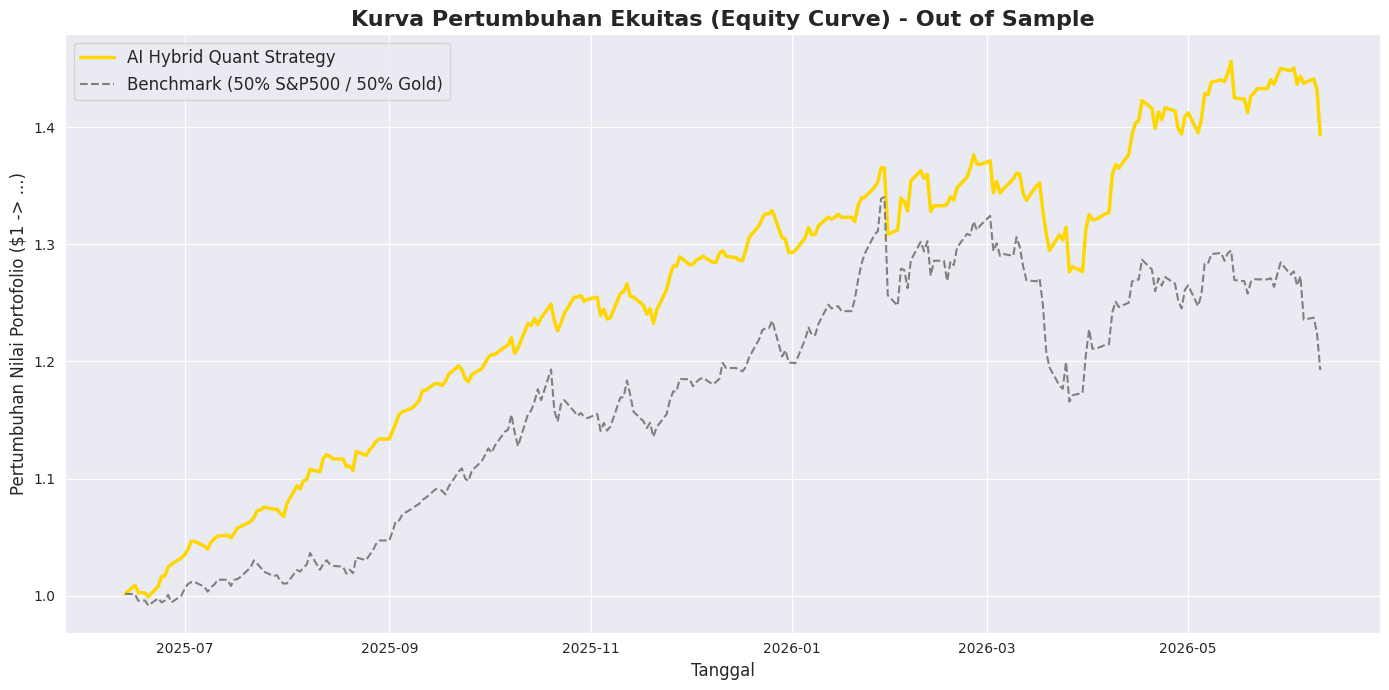

In [9]:
# ==============================================================================
# 7. INSTITUTIONAL BACKTESTING ENGINE (OUT-OF-SAMPLE) - BUG FIXED
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class VectorizedBacktester:
    def __init__(self, df_test, execution_threshold):
        self.df = df_test.copy()
        self.threshold = execution_threshold

    def run(self, predictions, gold_weights, sp500_weights):
        print("\n[5] Menjalankan Simulasi Backtest Out-of-Sample...")

        # 1. Menghasilkan Sinyal Trading (Long = 1, Short = -1, Hold = 0)
        # Sinyal difilter oleh execution_threshold untuk menghindari noise
        conditions = [
            predictions > self.threshold,
            predictions < -self.threshold
        ]
        choices = [1, -1]
        self.df['Gold_Signal'] = np.select(conditions, choices, default=0)

        # 2. Injeksi Alokasi Fuzzy (Regime-Aware)
        self.df['Gold_Weight'] = gold_weights
        self.df['SP500_Weight'] = sp500_weights

        # 3. Kalkulasi Return Strategi
        self.df['Strategy_Gold_Return'] = self.df['Gold_Weight'] * self.df['Gold_Signal'] * self.df['XAUUSD_Return']
        self.df['Strategy_SP500_Return'] = self.df['SP500_Weight'] * self.df['SP500_Return']
        self.df['Total_Strategy_Return'] = self.df['Strategy_Gold_Return'] + self.df['Strategy_SP500_Return']

        # 4. Kalkulasi Benchmark (Beli dan Tahan 50% Emas, 50% S&P500)
        self.df['Benchmark_Return'] = 0.5 * self.df['XAUUSD_Return'] + 0.5 * self.df['SP500_Return']

        # 5. Pertumbuhan Ekuitas Kumulatif (Compounding)
        self.df['Cum_Strategy'] = (1 + self.df['Total_Strategy_Return']).cumprod()
        self.df['Cum_Benchmark'] = (1 + self.df['Benchmark_Return']).cumprod()

        return self.calculate_metrics()

    def calculate_metrics(self):
        strat_returns = self.df['Total_Strategy_Return']

        # Metrik 1: Annualized Return & Volatility
        days = len(self.df)
        ann_return = (self.df['Cum_Strategy'].iloc[-1]) ** (252/days) - 1
        ann_vol = strat_returns.std() * np.sqrt(252)

        # Metrik 2: Sharpe Ratio
        sharpe = ann_return / ann_vol if ann_vol != 0 else 0

        # Metrik 3: Maximum Drawdown
        peak = self.df['Cum_Strategy'].cummax()
        drawdown = (self.df['Cum_Strategy'] - peak) / peak
        max_dd = drawdown.min()

        # Metrik 4: Win Rate Emas
        active_trades = self.df[self.df['Gold_Signal'] != 0]
        if len(active_trades) > 0:
            winning_trades = active_trades[active_trades['Strategy_Gold_Return'] > 0]
            win_rate = len(winning_trades) / len(active_trades)
        else:
            win_rate = 0.0

        print("\n" + "="*50)
        print("📈 HASIL BACKTEST OUT-OF-SAMPLE (TEST SET)".center(50))
        print("="*50)
        print(f"• Total Hari Trading       : {days} Hari")
        print(f"• Cumulative Return (Net)  : {(self.df['Cum_Strategy'].iloc[-1] - 1):.2%}")
        print(f"• Annualized Return        : {ann_return:.2%}")
        print(f"• Maximum Drawdown         : {max_dd:.2%}")
        print(f"• Sharpe Ratio             : {sharpe:.2f}")
        print(f"• Win Rate Sinyal Emas     : {win_rate:.2%}")
        print(f"• Persentase Mode HOLD     : {len(self.df[self.df['Gold_Signal'] == 0]) / days:.2%} (Efek Filter)")
        print("="*50)

        self.plot_equity_curve()
        return self.df

    def plot_equity_curve(self):
        sns.set_style("darkgrid")
        plt.figure(figsize=(14, 7))
        plt.plot(self.df.index, self.df['Cum_Strategy'], label='AI Hybrid Quant Strategy', color='#FFD700', linewidth=2.5)
        plt.plot(self.df.index, self.df['Cum_Benchmark'], label='Benchmark (50% S&P500 / 50% Gold)', color='#808080', linestyle='--', linewidth=1.5)

        plt.title('Kurva Pertumbuhan Ekuitas (Equity Curve) - Out of Sample', fontsize=16, fontweight='bold')
        plt.xlabel('Tanggal', fontsize=12)
        plt.ylabel('Pertumbuhan Nilai Portofolio ($1 -> ...)', fontsize=12)
        plt.legend(loc='upper left', fontsize=12)
        plt.tight_layout()
        plt.show()

# ==============================================================================
# EKSEKUSI BACKTEST PADA DATA TEST
# ==============================================================================
if __name__ == "__main__":
    # --- [PERBAIKAN BUG] Mendefinisikan Variabel yang Hilang ---
    seq_len = 10
    X_test = X_tensor[train_size:]

    # Menyiapkan Indeks Waktu yang Tepat untuk Test Set
    df_test = df_raw.iloc[seq_len + train_size:].copy()

    # 1. Mendapatkan Prediksi Model (Batch Inference pada Test Set)
    trained_model.eval()
    trained_model.dropout.train() # Aktifkan MC Dropout

    mc_simulations_backtest = 10
    test_preds_list = []

    with torch.no_grad():
        for _ in range(mc_simulations_backtest):
            preds_scaled = trained_model(X_test.to(DEVICE)).cpu().numpy()
            test_preds_list.append(preds_scaled)

    # Rata-rata dari simulasi Monte Carlo untuk setiap hari di test set
    mean_test_preds_scaled = np.mean(test_preds_list, axis=0)

    # Mengembalikan hasil prediksi ke skala return logaritmik riil
    mean_test_preds = pipeline.scaler_y.inverse_transform(mean_test_preds_scaled).flatten()

    # 2. Mendapatkan Rekam Jejak Alokasi Fuzzy dari Rezim S&P500
    # [PERBAIKAN] Dihitung dari seluruh rentang (df_raw) agar nilai di Test Set akurat
    sp500_all = df_raw['SP500_Return']
    vol_window = 20
    z_threshold = -1.5

    rolling_mean_all = sp500_all.rolling(window=vol_window).mean()
    rolling_std_all = sp500_all.rolling(window=vol_window).std()
    z_scores_all = (sp500_all - rolling_mean_all) / (rolling_std_all + 1e-8)

    # Slicing z_score murni hanya untuk di bagian test set
    z_scores_test = z_scores_all.iloc[seq_len + train_size:]

    gold_alloc_history = 1 / (1 + np.exp(z_scores_test - z_threshold))
    gold_alloc_history = np.clip(gold_alloc_history, 0.10, 0.90).values
    sp500_alloc_history = 1.0 - gold_alloc_history

    # 3. Jalankan Engine Backtester
    historical_std = np.std(df_raw['XAUUSD_Return'].values)
    exec_thresh = 0.15 * historical_std

    backtester = VectorizedBacktester(df_test, execution_threshold=exec_thresh)
    backtest_results = backtester.run(predictions=mean_test_preds,
                                      gold_weights=gold_alloc_history,
                                      sp500_weights=sp500_alloc_history)